In [1]:
import pandas as pd
import torch
import numpy as np
import torch.nn as nn
import joblib 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold,train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from tqdm import tqdm
from torch.utils.data import DataLoader,TensorDataset

/home/anmino/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv("train.csv")
df.drop("id",axis=1,inplace=True)

In [3]:
df.duplicated().sum()

2841

In [4]:
print(f"Duplicated: {df.duplicated().sum() / len(df) * 100:.2f}%")

Duplicated: 0.38%


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
print(f"Duplicated: {df.duplicated().sum() / len(df) * 100:.2f}%")

Duplicated: 0.00%


In [7]:
df["Sex"] = pd.get_dummies(df["Sex"],drop_first=True,dtype="int")

In [8]:
df.head(2)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,0,64,163.0,60.0,8.0,85.0,39.7,34.0


In [9]:
x = df.drop("Calories",axis=1).values
y = df["Calories"].values

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
scaler_x = StandardScaler()
x_train = scaler_x.fit_transform(x_train)
x_test = scaler_x.transform(x_test)

In [12]:
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test = scaler_y.transform(y_test.reshape(-1,1))

In [13]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)

In [14]:
y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [15]:
train_dataset = TensorDataset(
    x_train,
    y_train,
)
test_dataset = TensorDataset(
    x_test,
    y_test
)

In [16]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=100
)

test_loader = DataLoader(
    test_dataset,
    shuffle=True,
    batch_size=100
)

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.res1 = nn.Linear(dim,dim)
        self.ln1 = nn.LayerNorm(dim)

        self.res2 = nn.Linear(dim,dim)
        self.ln2 = nn.LayerNorm(dim)

        self.relu = nn.ReLU()

    def forward(self,x):
        d = x
        out = self.res1(x)
        out = self.ln1(out)
        out = self.relu(out)

        out = self.res2(out)
        out = self.ln2(out)

        out = out + d

        out = self.relu(out)

        return out
    
class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.LayerNorm(128),
            nn.ReLU()
        )
        self.resb1 = ResidualBlock(128)
        self.resb2 = ResidualBlock(128)

        self.output = nn.Linear(128,1)

    def forward(self,x):
        x = self.input_layer(x)
        x = self.resb1(x)
        x = self.resb2(x)

        x = self.output(x)
        return x

In [18]:
model = MyModel(7)

In [19]:
for name,param in model.named_parameters():
    print(name,param.shape)

input_layer.0.weight torch.Size([128, 7])
input_layer.0.bias torch.Size([128])
input_layer.1.weight torch.Size([128])
input_layer.1.bias torch.Size([128])
resb1.res1.weight torch.Size([128, 128])
resb1.res1.bias torch.Size([128])
resb1.ln1.weight torch.Size([128])
resb1.ln1.bias torch.Size([128])
resb1.res2.weight torch.Size([128, 128])
resb1.res2.bias torch.Size([128])
resb1.ln2.weight torch.Size([128])
resb1.ln2.bias torch.Size([128])
resb2.res1.weight torch.Size([128, 128])
resb2.res1.bias torch.Size([128])
resb2.ln1.weight torch.Size([128])
resb2.ln1.bias torch.Size([128])
resb2.res2.weight torch.Size([128, 128])
resb2.res2.bias torch.Size([128])
resb2.ln2.weight torch.Size([128])
resb2.ln2.bias torch.Size([128])
output.weight torch.Size([1, 128])
output.bias torch.Size([1])


In [20]:
loss_function = nn.MSELoss()
optimization_function = torch.optim.AdamW(
    model.parameters(),
    lr=0.01,
    weight_decay=0.01
)

In [21]:
train_loss_hist = []
test_loss_hist = []

epochs = 20
progress_bar = tqdm(range(epochs),colour="green")

for epoch in progress_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optimization_function.zero_grad()
        train_pred = model(batch_train_x)
        train_loss = loss_function(train_pred,batch_train_y)
        train_loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),
                                 max_norm=1.0)
        optimization_function.step()
        total_train_loss += train_loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_test_x,batch_test_y in test_loader:
            test_pred = model(batch_test_x)
            test_loss = loss_function(test_pred,batch_test_y)
            total_test_loss += test_loss.item()
        avg_test_loss = total_test_loss/ len(test_loader)

        train_loss_hist.append(avg_train_loss)
        test_loss_hist.append(avg_test_loss)

        torch.save({
            "Epoch":epoch,
            "Train Loss":avg_train_loss,
            "Test Loss": avg_test_loss,
            "Optimizer":optimization_function.state_dict()
        },f"Advance_model_testing/Checkpoint_{epoch + 1}.pth")

        progress_bar.set_postfix({
            "Epoch":epoch,
            "Train Loss":avg_train_loss,
            "Test Loss":avg_test_loss
        })

100%|██████████| 20/20 [08:24<00:00, 25.22s/it, Epoch=19, Train Loss=0.00422, Test Loss=0.00385]


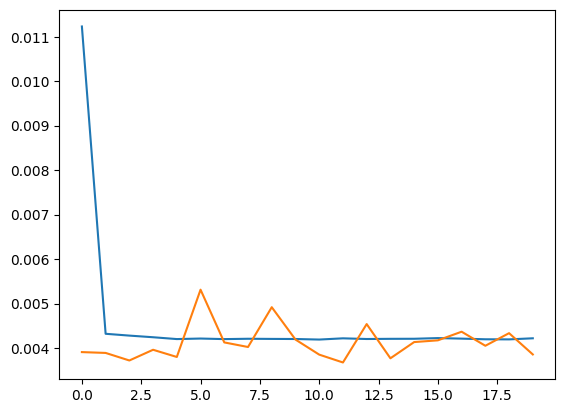

In [22]:
plt.plot(train_loss_hist,label="train")
plt.plot(test_loss_hist,label="test")

In [23]:
model.eval()

MyModel(
  (input_layer): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
  )
  (resb1): ResidualBlock(
    (res1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (res2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (relu): ReLU()
  )
  (resb2): ResidualBlock(
    (res1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (res2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (relu): ReLU()
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

In [24]:
train_actual = []
train_pre = []
with torch.no_grad():
    for batch_x_data,batch_y_data in train_loader:
        prd_data = model(batch_x_data)
        train_pre.extend(prd_data)
        train_actual.extend(batch_y_data)
    

In [25]:
train_actual = scaler_y.inverse_transform(np.array(train_actual).reshape(-1,1))
train_pre = scaler_y.inverse_transform(np.array(train_pre).reshape(-1,1))

In [26]:
train_rmse = mean_squared_error(train_actual,train_pre)
train_mae = mean_absolute_error(train_actual,train_pre)
train_r2 = r2_score(train_actual,train_pre)

In [28]:
actual = []
pred = []
with torch.no_grad():

    for x_d,y_d in test_loader:
        test_pre = model(x_d)
        pred.extend(test_pre.numpy())
        actual.extend(y_d.numpy())

In [29]:
pred = scaler_y.inverse_transform(np.array(pred).reshape(-1,1))
actual = scaler_y.inverse_transform(np.array(actual).reshape(-1,1))

In [30]:
pred.shape,actual.shape,len(y_test)

((149432, 1), (149432, 1), 149432)

In [31]:
rmse = mean_squared_error(actual,pred)
mae = mean_absolute_error(actual,pred)
r2 = r2_score(actual,pred)

In [32]:
print("========Train=======")
print(f"RMSE: {train_rmse}")
print(f"MAE: {train_mae}")
print(f"R2: {train_r2}")

print("========Test========")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

========Train=======
RMSE: 15.093639373779297
MAE: 2.430225133895874
R2: 0.9961269497871399
========Test========
RMSE: 15.017009735107422
MAE: 2.4335200786590576
R2: 0.9961287379264832


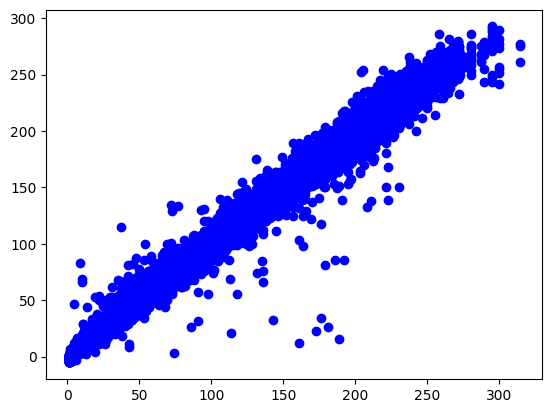

In [34]:
plt.scatter(actual,pred,color="blue")

In [35]:
import shap

/home/anmino/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
background = x_train[:100]

In [40]:
explainer = shap.DeepExplainer(
    model,
    background
)

In [43]:
explainer

In [44]:
shap_values = explainer.shap_values(
    x_test[:50],
    check_additivity=False
)

/home/anmino/.local/lib/python3.10/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")


In [55]:
f_names = ['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

In [59]:
shap_values = shap_values.squeeze(-1)

print(shap_values.shape)

(50, 7)


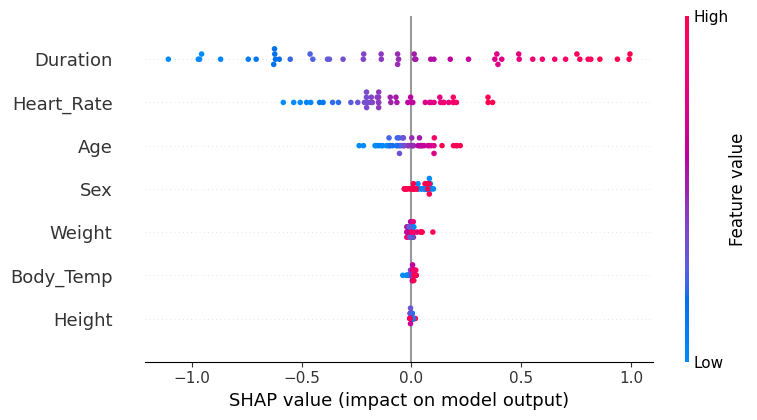

In [60]:
shap.summary_plot(
    shap_values,
    x_test[:50].numpy(),
    feature_names=f_names
)

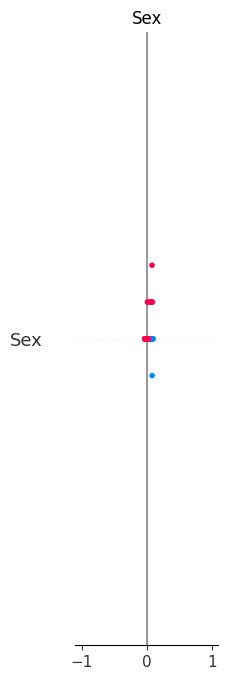

In [57]:
shap.summary_plot(
    shap_values,
    x_test[:50].numpy(),
    feature_names = f_names,
    plot_type="bar"
)

In [58]:
print(type(shap_values))
print(np.array(shap_values).shape)
print(len(f_names))
print(f_names)


<class 'numpy.ndarray'>
(50, 7, 1)
7
['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
